In [2]:
import pandas as pd

# Load the latest S&P 500 constituent list from GitHub
url = "https://raw.githubusercontent.com/fja05680/sp500/master/sp500.csv"
sp500_df = pd.read_csv(url)

# Extract tickers (column name may vary, often 'Symbol')
tickers = sp500_df['Symbol'].dropna().unique().tolist()
print(f"Loaded {len(tickers)} tickers")

Loaded 503 tickers


In [3]:
# Replace '.' with '-' for Yahoo Finance compatibility
tickers = [tk.replace('.', '-') for tk in tickers]

In [4]:
import yfinance as yf

# Download daily OHLCV data for all tickers
data = yf.download(tickers, start="2015-01-01", end="2026-01-01", group_by="ticker")

# Convert to your framework’s expected format
dfs = {}
for tk in tickers:
    try:
        df = data[tk].copy()
        df.columns = [c.lower() for c in df.columns]
        if not {"open","high","low","close","volume"} <= set(df.columns):
            print(f"Skipping {tk}: missing OHLCV")
            continue
        dfs[tk] = df.dropna()
    except Exception as e:
        print(f"Skipping {tk}: {e}")


/tmp/ipykernel_28560/3287983313.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2015-01-01", end="2026-01-01", group_by="ticker")
[*                      3%                       ]  16 of 503 completedERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: DAY"}}}
[********              17%                       ]  83 of 503 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DAY']: YFTzMissingError('possibly delisted; no timezone found')


In [5]:
print(type(data))
print(data.shape)
print(data.columns[:20])   # show first 20 columns
print(data.columns.levels) # show the multi-index levels

<class 'pandas.core.frame.DataFrame'>
(2766, 2516)
MultiIndex([('MPWR',   'Open'),
            ('MPWR',   'High'),
            ('MPWR',    'Low'),
            ('MPWR',  'Close'),
            ('MPWR', 'Volume'),
            ('NDSN',   'Open'),
            ('NDSN',   'High'),
            ('NDSN',    'Low'),
            ('NDSN',  'Close'),
            ('NDSN', 'Volume'),
            ('INTC',   'Open'),
            ('INTC',   'High'),
            ('INTC',    'Low'),
            ('INTC',  'Close'),
            ('INTC', 'Volume'),
            ( 'LVS',   'Open'),
            ( 'LVS',   'High'),
            ( 'LVS',    'Low'),
            ( 'LVS',  'Close'),
            ( 'LVS', 'Volume')],
           names=['Ticker', 'Price'])
[['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'ALLE', 'AMAT', 'AMCR', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANET', 'AON', 'AOS', 'APA', 'APD

In [6]:
if "DAY" in data.columns.get_level_values(0):
    print("DAY columns:", data["DAY"].columns)
    print("DAY head:\n", data["DAY"].head())
else:
    print("DAY not in dataset")

DAY columns: Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object', name='Price')
DAY head:
 Price       Open  High  Low  Close  Adj Close  Volume
Date                                                 
2015-01-02   NaN   NaN  NaN    NaN        NaN     NaN
2015-01-05   NaN   NaN  NaN    NaN        NaN     NaN
2015-01-06   NaN   NaN  NaN    NaN        NaN     NaN
2015-01-07   NaN   NaN  NaN    NaN        NaN     NaN
2015-01-08   NaN   NaN  NaN    NaN        NaN     NaN


In [7]:
valid_dfs = {}
bad_tickers = []

for tk in data.columns.levels[0]:
    df = data[tk].copy()

    # Drop rows that are all NaN
    df = df.dropna(how="all")
    if df.empty:
        print(f"Skipping {tk}: empty data")
        bad_tickers.append(tk)
        continue

    # Lowercase columns
    df.columns = [c.lower() for c in df.columns]

    # Must contain OHLCV
    required = {"open", "high", "low", "close", "volume"}
    if not required.issubset(df.columns):
        print(f"Skipping {tk}: missing OHLCV columns")
        bad_tickers.append(tk)
        continue

    # Must have a valid 1D close
    if df["close"].ndim > 1:
        print(f"Skipping {tk}: multiple close columns detected")
        bad_tickers.append(tk)
        continue

    valid_dfs[tk] = df

print(f"Final universe: {len(valid_dfs)} tickers")
print(f"Bad tickers: {bad_tickers}")


Skipping DAY: empty data
Final universe: 502 tickers
Bad tickers: ['DAY']


In [8]:
clean_dfs = {}
bad_tickers = []

for tk, df in dfs.items():
    # Drop rows that are all NaN
    df = df.dropna(how="all")
    if df.empty:
        bad_tickers.append(tk)
        continue

    # Lowercase columns
    df.columns = [c.lower() for c in df.columns]

    # Must contain OHLCV
    required = {"open", "high", "low", "close", "volume"}
    if not required.issubset(df.columns):
        bad_tickers.append(tk)
        continue

    # Must have a valid 1D close
    if df["close"].ndim > 1:
        bad_tickers.append(tk)
        continue

    clean_dfs[tk] = df

print(f"Final universe: {len(clean_dfs)} tickers")
print(f"Bad tickers: {bad_tickers}")


Final universe: 502 tickers
Bad tickers: ['DAY']


In [9]:
subset_dfs = {tk: clean_dfs[tk] for tk in list(clean_dfs.keys())[:10]}


  LambdaMART Cross-Sectional Ranking Strategy
  Universe  : n_long=2, n_short=2
  Horizon   : forward_days=1, n_relevance_bins=4
  Rebalance : D  |  min_hold=1d  |  TC=0.1bps

  [1/5] Building cross-sectional feature panel…
  Panel: 2566 dates × 10 tickers = 25660 rows
  Date range: 2015-10-16 – 2025-12-30
  Relevance distribution: {0: 7698, 1: 5132, 2: 5132, 3: 7698}

  [2/5] Walk-forward LambdaMART ranking (train=2y, test=3mo)…
  Selected 25 features via LGBMRanker importance.
  Fold 1: train 2015-10-16 – 2017-10-15 | test 2017-10-16 – 2018-01-12 | test_dates=62
  Fold 2: train 2015-10-16 – 2018-01-15 | test 2018-01-16 – 2018-04-13 | test_dates=62
  Fold 3: train 2015-10-16 – 2018-04-15 | test 2018-04-16 – 2018-07-13 | test_dates=63
  Fold 4: train 2015-10-16 – 2018-07-15 | test 2018-07-16 – 2018-10-15 | test_dates=65
  Fold 5: train 2015-10-16 – 2018-10-15 | test 2018-10-16 – 2019-01-15 | test_dates=62
  Fold 6: train 2015-10-16 – 2019-01-15 | test 2019-01-16 – 2019-04-15 | test_da

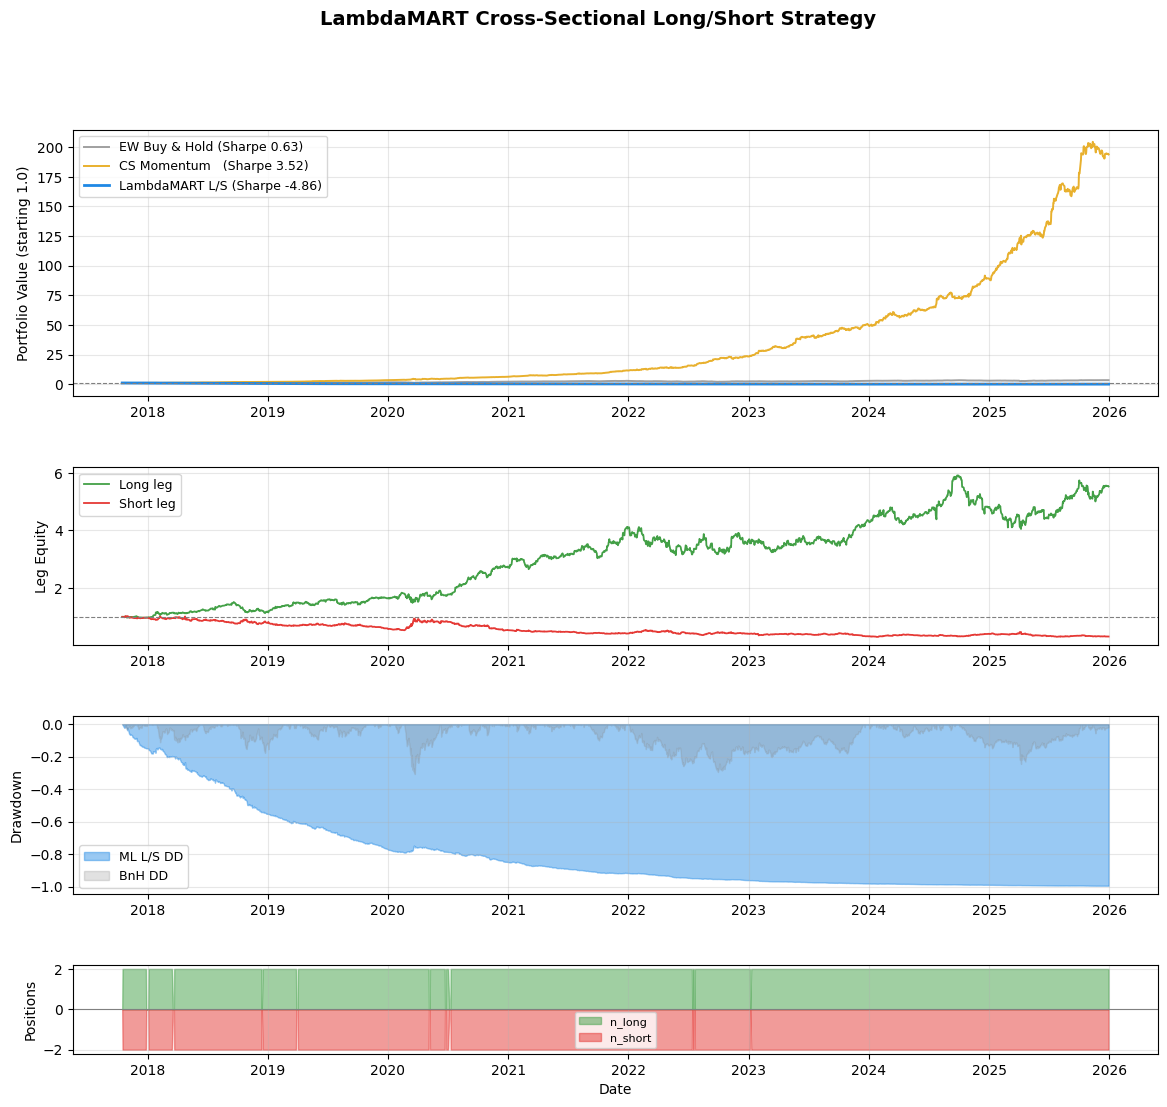

In [11]:
"""
ml_ranking_strategy.py
=======================
Cross-sectional LambdaMART trading framework for a universe of OHLCV stocks.

Architecture overview
---------------------
Instead of training per-ticker classifiers, this framework treats each
*trading day* as a "query" in learning-to-rank terminology. Every stock in
the universe is an "item" and the model learns to rank all items within each
day's query by their expected next-period return.

At inference time the model scores every stock. The top-N stocks are longed
and the bottom-N stocks are shorted, forming a dollar-neutral long/short
portfolio that is rebalanced daily (or at a configurable frequency).

Literature sources
------------------
- Poh et al. (2020): LambdaMART for cross-sectional momentum; Sharpe tripled
  over classical CSM strategies; listwise ranking beats regress-then-rank.
- Zhang et al. (2023): CNN-Bi-LSTM + genetic-algorithm MACD tuning; hybrid
  strategy beats pure MA rules; adds 35% annualised return.
- Chen et al. (2020): LightGBM achieves R²=0.798; min-variance CVaR portfolios
  reduce tail risk.
- Wang & Dong (2025): 37 indicators across 5 categories; XGBoost-SHAP +
  LightGBM cross-selection; Bayesian-optimised ANN.
- Dey et al. (2025): LSTM 85.3% accuracy / Sharpe 1.45 with MA + Stochastic
  RSI + Price-Volume actions; all three feature groups matter.
- Liu et al. (2024): FinRL-Meta highlights low SNR, survivorship bias, and
  overfitting as the three key FinRL challenges; dynamic rolling windows help.
- Jegadeesh & Titman (1993): Classical cross-sectional momentum; long winners,
  short losers.

Design decisions
----------------
1. LambdaMART (LGBMRanker, objective='lambdarank') as the ranking engine.
   Directly optimises NDCG across stocks-per-day rather than predicting
   individual returns. This is the key architectural change from the original
   classification framework.

2. Query = trading day. Group sizes passed to LGBMRanker describe how many
   stocks exist in the universe on each date. The model ranks ALL stocks
   within each daily query simultaneously — learning pairwise relationships
   between them.

3. Relevance label = integer-binned future N-day return (0–4 scale).
   Buckets are computed cross-sectionally per date (quintile ranking) so
   the label captures *relative* outperformance, not absolute return.
   This directly mirrors the long/short objective.

4. Rich 5-category feature set (42 features) identical to Wang & Dong (2025)
   and Dey et al. (2025). Features are computed per-ticker then stacked into
   a cross-sectional panel.

5. Walk-forward expanding-window validation: the training set grows with
   each fold; the test window is fixed. Feature selection runs once on the
   first fold via LightGBM importance scores.

6. Portfolio construction: daily rank the universe with the trained model;
   long the top-K stocks, short the bottom-K stocks. Dollar-neutral: long
   side and short side are equal-weight and equal-sized.

7. Regime filter (optional): suppress signals when the cross-sectional
   median ADX < 20 (the whole market is choppy) or when fewer than
   min_universe_size tickers have valid signals.

8. Minimum-hold filter (optional): a per-ticker lock prevents turning over
   positions faster than min_hold_days, cutting friction.

9. Transaction costs: applied on each position change, separately for long
   and short legs.

10. Baselines: equal-weight buy-and-hold, cross-sectional 12-1 momentum
    (long top decile, short bottom decile), and long-only ML ensemble from
    the original framework.

Accepted input formats
----------------------
Multi-ticker dict of DataFrames:
    {ticker: pd.DataFrame with DatetimeIndex and columns open/high/low/close/volume}

Or a folder of CSVs named <TICKER>.csv.

Usage
-----
    results = run_ranking_strategy(
        dfs={"AAPL": aapl_df, "MSFT": msft_df, ...},
        n_long=2, n_short=2,
        rebalance_freq="D",       # 'D' daily, 'W' weekly, 'ME' month-end
        train_years=2,
        test_months=3,
        transaction_cost=0.001,
    )

    # Or load from a directory of CSVs
    results = run_ranking_strategy(
        data_dir="data/",
        n_long=2, n_short=2,
    )

Requirements
------------
    pip install pandas numpy scikit-learn lightgbm xgboost matplotlib scipy
"""

from __future__ import annotations

import warnings
warnings.filterwarnings("ignore")

import math
import os
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from scipy.stats import rankdata
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from lightgbm import LGBMRanker
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# ─────────────────────────────────────────────────────────────
# 1.  FEATURE ENGINEERING  (5-category framework, Wang & Dong 2025)
# ─────────────────────────────────────────────────────────────

def _safe_div(a: pd.Series, b: pd.Series, fill: float = 0.0) -> pd.Series:
    return a.where(b.abs() > 1e-12, fill) / b.where(b.abs() > 1e-12, 1.0)


def compute_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build a 42-feature matrix from raw OHLCV data for a single ticker.
    Identical feature set to the original framework (Wang & Dong 2025).
    """
    df = df.copy()
    df.columns = [c.lower().strip() for c in df.columns]
    col_map = {"adj close": "close", "adjusted close": "close", "adj_close": "close"}
    df.rename(columns=col_map, inplace=True)
    required = {"open", "high", "low", "close", "volume"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    if df["close"].ndim > 1:
        raise ValueError(f"Multiple close columns detected")

    o, h, l, c, v = (df[k] for k in ["open", "high", "low", "close", "volume"])

    # ── 1. Overlap Studies ──────────────────────────────────
    for n in [5, 10, 20, 50, 200]:
        df[f"sma_{n}"] = c.rolling(n).mean()
    for n in [12, 26]:
        df[f"ema_{n}"] = c.ewm(span=n, adjust=False).mean()
    ema12 = df["ema_12"]
    df["dema_12"] = 2 * ema12 - ema12.ewm(span=12, adjust=False).mean()

    def wma(series: pd.Series, n: int) -> pd.Series:
        weights = np.arange(1, n + 1, dtype=float)
        return series.rolling(n).apply(
            lambda x: np.dot(x, weights) / weights.sum(), raw=True
        )
    df["wma_10"] = wma(c, 10)

    bb_mid = df["sma_20"]
    bb_std = c.rolling(20).std()
    df["bb_upper"] = bb_mid + 2 * bb_std
    df["bb_lower"] = bb_mid - 2 * bb_std
    df["bb_width"]  = _safe_div(df["bb_upper"] - df["bb_lower"], bb_mid)
    df["bb_pct"]    = _safe_div(c - df["bb_lower"], df["bb_upper"] - df["bb_lower"])

    df["price_sma5_ratio"]   = _safe_div(c, df["sma_5"])   - 1
    df["price_sma20_ratio"]  = _safe_div(c, df["sma_20"])  - 1
    df["price_sma50_ratio"]  = _safe_div(c, df["sma_50"])  - 1
    df["price_sma200_ratio"] = _safe_div(c, df["sma_200"]) - 1

    # ── 2. Momentum ─────────────────────────────────────────
    delta = c.diff()
    gain  = delta.clip(lower=0)
    loss  = (-delta).clip(lower=0)
    avg_g = gain.ewm(alpha=1/14, adjust=False).mean()
    avg_l = loss.ewm(alpha=1/14, adjust=False).mean()
    df["rsi_14"] = 100 - 100 / (1 + _safe_div(avg_g, avg_l, fill=1e9))

    rsi = df["rsi_14"]
    df["stoch_rsi"] = _safe_div(rsi - rsi.rolling(14).min(),
                                 rsi.rolling(14).max() - rsi.rolling(14).min())

    df["macd"]        = df["ema_12"] - df["ema_26"]
    df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
    df["macd_hist"]   = df["macd"] - df["macd_signal"]

    tr = pd.concat([h - l, (h - c.shift(1)).abs(), (l - c.shift(1)).abs()],
                   axis=1).max(axis=1)
    dm_up   = (h - h.shift(1)).clip(lower=0)
    dm_down = (l.shift(1) - l).clip(lower=0)
    dm_up   = dm_up.where(dm_up > dm_down, 0)
    dm_down = dm_down.where(dm_down > dm_up, 0)
    atr14   = tr.ewm(span=14, adjust=False).mean()
    di_up   = 100 * _safe_div(dm_up.ewm(span=14, adjust=False).mean(), atr14)
    di_down = 100 * _safe_div(dm_down.ewm(span=14, adjust=False).mean(), atr14)
    dx      = 100 * _safe_div((di_up - di_down).abs(), di_up + di_down)
    df["adx_14"] = dx.ewm(span=14, adjust=False).mean()

    hh = h.rolling(14).max()
    ll = l.rolling(14).min()
    df["willr_14"] = -100 * _safe_div(hh - c, hh - ll)

    aroon_up   = 100 * (25 - h.rolling(25).apply(
        lambda x: 25 - np.argmax(x), raw=True)) / 25
    aroon_down = 100 * (25 - l.rolling(25).apply(
        lambda x: 25 - np.argmin(x), raw=True)) / 25
    df["aroon_osc"] = aroon_up - aroon_down

    df["roc_10"] = _safe_div(c - c.shift(10), c.shift(10)) * 100
    df["mom_10"] = c - c.shift(10)

    pos_sum = gain.rolling(14).sum()
    neg_sum = loss.rolling(14).sum()
    df["cmo_14"] = 100 * _safe_div(pos_sum - neg_sum, pos_sum + neg_sum)

    # ── 3. Volatility ────────────────────────────────────────
    df["atr_14"]  = atr14
    ret1          = c.pct_change()
    df["hvol_10"] = ret1.rolling(10).std() * math.sqrt(252)
    df["hvol_20"] = ret1.rolling(20).std() * math.sqrt(252)
    df["tr_norm"] = _safe_div(tr, c)

    # ── 4. Volume ────────────────────────────────────────────
    sign        = np.sign(c.diff()).fillna(0)
    df["obv"]   = (sign * v).cumsum()
    clv         = _safe_div((c - l) - (h - c), h - l)
    df["ad_line"] = (clv * v).cumsum()
    df["pvt"]   = (_safe_div(c - c.shift(1), c.shift(1)) * v).cumsum()
    df["vol_ratio"]  = _safe_div(v, v.rolling(20).mean())
    df["force_idx"]  = c.diff() * v

    # ── 5. Price Transform ───────────────────────────────────
    body   = (c - o).abs()
    range_ = (h - l).clip(lower=1e-9)
    df["body_ratio"]   = _safe_div(body, range_)
    df["upper_shadow"] = _safe_div(h - pd.concat([c, o], axis=1).max(axis=1), range_)
    df["lower_shadow"] = _safe_div(pd.concat([c, o], axis=1).min(axis=1) - l, range_)
    df["gap"]          = _safe_div(o - c.shift(1), c.shift(1))

    for n in [1, 3, 5, 10]:
        df[f"ret_{n}d"] = c.pct_change(n)

    df = df.dropna()
    return df


FEATURE_COLS: List[str] = [
    "sma_5", "sma_10", "sma_20", "sma_50",
    "ema_12", "ema_26", "dema_12", "wma_10",
    "bb_width", "bb_pct",
    "price_sma5_ratio", "price_sma20_ratio", "price_sma50_ratio", "price_sma200_ratio",
    "rsi_14", "stoch_rsi",
    "macd", "macd_signal", "macd_hist",
    "adx_14", "willr_14", "aroon_osc",
    "roc_10", "mom_10", "cmo_14",
    "atr_14", "hvol_10", "hvol_20", "tr_norm",
    "vol_ratio", "force_idx", "obv", "ad_line", "pvt",
    "body_ratio", "upper_shadow", "lower_shadow", "gap",
    "ret_1d", "ret_3d", "ret_5d", "ret_10d",
]


# ─────────────────────────────────────────────────────────────
# 2.  PANEL BUILDER
#     Combine individual ticker DataFrames into a cross-sectional panel
# ─────────────────────────────────────────────────────────────

def build_panel(
    dfs: Dict[str, pd.DataFrame],
    forward_days: int = 5,
    n_relevance_bins: int = 4,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Compute features for each ticker and stack into a joint panel DataFrame.

    Each row is (date, ticker).  The relevance label is the cross-sectional
    quintile rank of the forward return — 0 (worst) to n_relevance_bins-1
    (best) — computed per date so the model learns relative ordering.

    LGBMRanker requires INTEGER relevance labels. Using quintile bins
    (default 4 bins → labels 0–3) maps naturally to long/short selection:
      - label 3 → expected top performers → LONG candidates
      - label 0 → expected bottom performers → SHORT candidates

    Parameters
    ----------
    forward_days      : future horizon for the forward return target.
    n_relevance_bins  : number of bins for cross-sectional relevance
                        (default 4 gives quartile labels 0-3).
    """
    records = []
    skipped = []

    for ticker, df_raw in dfs.items():
        try:
            df_feat = compute_features(df_raw)
            df_feat["ticker"] = ticker
            df_feat["fwd_ret"] = df_feat["close"].pct_change(forward_days).shift(-forward_days)
            records.append(df_feat)
        except Exception as exc:
            skipped.append(f"{ticker}: {exc}")

    if skipped and verbose:
        for s in skipped:
            print(f"  [WARN] Feature computation skipped — {s}")

    if not records:
        raise ValueError("No valid ticker data after feature computation.")

    panel = pd.concat(records).sort_index()

    # Cross-sectional quintile relevance label per date
    def _quintile_label(s: pd.Series) -> pd.Series:
        if s.isna().all() or len(s.dropna()) < n_relevance_bins:
            return pd.Series(np.nan, index=s.index)
        return pd.qcut(s.rank(method="first"), q=n_relevance_bins,
                       labels=False, duplicates="drop")

    panel["relevance"] = (
        panel.groupby(level=0)["fwd_ret"]
             .transform(_quintile_label)
             .astype("Int64")
    )

    # Drop rows with missing features or missing label
    panel = panel.dropna(subset=FEATURE_COLS + ["relevance", "fwd_ret"])
    panel["relevance"] = panel["relevance"].astype(int)

    if verbose:
        dates = panel.index.unique()
        tickers = panel["ticker"].unique()
        print(f"  Panel: {len(dates)} dates × {len(tickers)} tickers "
              f"= {len(panel)} rows")
        print(f"  Date range: {dates.min().date()} – {dates.max().date()}")
        vc = panel["relevance"].value_counts().sort_index()
        print(f"  Relevance distribution: {vc.to_dict()}")

    return panel


# ─────────────────────────────────────────────────────────────
# 3.  LAMBDAMART MODEL
# ─────────────────────────────────────────────────────────────

def _build_ranker() -> LGBMRanker:
    """
    LambdaMART ranker (LightGBM).

    Key parameters
    --------------
    objective='lambdarank' : LambdaMART gradient objective optimising NDCG.
    label_gain             : Maps integer labels → gain values for NDCG.
                             Default gain = 2^label - 1; here labels are
                             0-3, so gains are 0, 1, 3, 7.
    lambdarank_truncation_level : focus NDCG calculation on the top-K rank
                             positions — set to n_long + n_short so the model
                             concentrates on getting the extremes right.
    """
    return LGBMRanker(
        objective="lambdarank",
        boosting_type="gbdt",
        n_estimators=400,
        learning_rate=0.03,
        max_depth=5,
        num_leaves=31,
        min_child_samples=10,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        verbose=-1,
        n_jobs=-1,
        # Customise label gains so 0-3 labels map to meaningful NDCG gains
        # Default: label_gain[i] = 2^i - 1  →  [0, 1, 3, 7]
        # This is already appropriate for 4-level relevance
    )


# ─────────────────────────────────────────────────────────────
# 4.  FEATURE SELECTION  (LightGBM importance, Wang & Dong 2025)
# ─────────────────────────────────────────────────────────────

def select_features_ranker(
    X_train: np.ndarray,
    y_train: np.ndarray,
    groups_train: np.ndarray,
    feature_names: List[str],
    top_k: int = 25,
) -> List[str]:
    """
    Rank features by LGBMRanker importance and keep the top-k.
    A lighter version of the cross-selection from Wang & Dong (2025),
    adapted for the ranking objective.
    """
    ranker = _build_ranker()
    ranker.fit(X_train, y_train, group=groups_train)
    imp = ranker.feature_importances_

    order = np.argsort(imp)[::-1]
    selected = [feature_names[i] for i in order[:top_k]]
    return selected


# ─────────────────────────────────────────────────────────────
# 5.  WALK-FORWARD RANKING
# ─────────────────────────────────────────────────────────────

def _panel_to_train_arrays(
    panel_slice: pd.DataFrame,
    feature_cols: List[str],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Convert a panel slice to (X, y, groups) required by LGBMRanker.

    groups[i] = number of stocks in the i-th query (date).
    Rows must be sorted by date first, then by ticker within each date.
    """
    panel_slice = panel_slice.sort_index().sort_values(
        ["ticker"], kind="stable"
    )
    X = panel_slice[feature_cols].values.astype(np.float32)
    y = panel_slice["relevance"].values.astype(np.int32)

    # Count stocks per date for the group array
    groups = panel_slice.groupby(level=0).size().values.astype(np.int32)
    return X, y, groups


def walk_forward_ranking(
    panel: pd.DataFrame,
    feature_cols: List[str],
    train_years: int = 2,
    test_months: int = 3,
    top_k_features: int = 25,
    verbose: bool = True,
) -> Tuple[pd.DataFrame, List[str]]:
    """
    Expanding-window walk-forward training and scoring.

    Each fold trains LGBMRanker on the growing training window and produces
    a ranking score for every (date, ticker) in the test window.

    Returns
    -------
    panel_scored : original panel with 'rank_score' column added.
    selected_features : feature subset after importance selection.
    """
    panel = panel.copy().sort_index()
    dates = panel.index.unique().sort_values()
    start = dates[0]
    end   = dates[-1]

    train_end = start + pd.DateOffset(years=train_years) - pd.Timedelta(days=1)
    if train_end >= end:
        raise ValueError(
            f"Insufficient data for {train_years}-year training window. "
            "Use a longer date range or reduce train_years."
        )

    score_chunks: List[pd.DataFrame] = []
    selected_features: Optional[List[str]] = None
    fold = 0

    while train_end < end:
        test_end = min(train_end + pd.DateOffset(months=test_months), end)

        train_slice = panel.loc[start:train_end]
        test_slice  = panel.loc[
            panel.index > train_end
        ].loc[:test_end]

        train_dates = train_slice.index.unique()
        test_dates  = test_slice.index.unique()

        if len(train_dates) < 60 or len(test_dates) < 1:
            train_end = test_end
            continue

        X_tr, y_tr, g_tr = _panel_to_train_arrays(train_slice, feature_cols)

        # Standardise (tree rankers are invariant, but helps convergence)
        scaler   = StandardScaler()
        X_tr_s   = scaler.fit_transform(X_tr)

        # Feature selection on first fold only
        if fold == 0:
            selected_features = select_features_ranker(
                X_tr_s, y_tr, g_tr, feature_cols, top_k=top_k_features
            )
            if verbose:
                print(f"  Selected {len(selected_features)} features via "
                      "LGBMRanker importance.")

        sel_idx  = [feature_cols.index(f) for f in selected_features]
        X_tr_sel = X_tr_s[:, sel_idx]

        # Fit ranker
        ranker = _build_ranker()
        ranker.fit(X_tr_sel, y_tr, group=g_tr)

        # Score test set — LGBMRanker.predict() is pointwise; no group needed
        test_slice_sorted = test_slice.sort_index()
        X_te = scaler.transform(
            test_slice_sorted[feature_cols].values.astype(np.float32)
        )[:, sel_idx]
        scores = ranker.predict(X_te)

        chunk = test_slice_sorted[["ticker", "fwd_ret", "relevance"]].copy()
        chunk["rank_score"] = scores
        score_chunks.append(chunk)

        if verbose:
            ndates_te = len(test_dates)
            print(f"  Fold {fold+1}: train {start.date()} – {train_end.date()} | "
                  f"test {test_dates.min().date()} – {test_dates.max().date()} | "
                  f"test_dates={ndates_te}")

        fold += 1
        train_end = test_end

    if not score_chunks:
        raise ValueError("No walk-forward folds produced.")

    scored = pd.concat(score_chunks).sort_index()

    # Merge scores back into original panel (training rows get NaN score)
    panel_out = panel.join(scored[["rank_score"]], how="left")
    return panel_out, selected_features


# ─────────────────────────────────────────────────────────────
# 6.  SIGNAL GENERATION — daily long/short selection
# ─────────────────────────────────────────────────────────────

def build_daily_positions(
    panel_scored: pd.DataFrame,
    n_long: int = 2,
    n_short: int = 2,
    rebalance_freq: str = "D",
    regime_filter: bool = True,
    min_universe_size: int = 5,
    min_hold_days: int = 1,
    verbose: bool = False,
) -> pd.DataFrame:
    """
    Convert daily rank scores into a position matrix.

    Parameters
    ----------
    panel_scored     : output of walk_forward_ranking (index=date, col=ticker).
    n_long           : number of stocks to long each period (top ranked).
    n_short          : number of stocks to short each period (bottom ranked).
    rebalance_freq   : 'D' daily, 'W' weekly, 'ME' month-end.
    regime_filter    : suppress all signals when cross-sectional median ADX < 20
                       (whole market in low-trend condition).
    min_universe_size: skip dates with fewer valid tickers than this.
    min_hold_days    : minimum bars to hold a position before reversal allowed.

    Returns
    -------
    positions : DataFrame, index=date, columns=ticker, values in {-1, 0, +1}.
                +1 = long, -1 = short, 0 = flat.
    """
    # Only use dates that have rank scores (i.e., test-window dates)
    scored = panel_scored.dropna(subset=["rank_score"]).copy()
    scored = scored.sort_index()

    # Resample to desired rebalancing frequency: take the last date in each period
    all_dates = scored.index.unique()
    if rebalance_freq != "D":
        # For non-daily: find the last date in each period
        tmp_series = pd.Series(all_dates, index=all_dates)
        period_ends = tmp_series.resample(rebalance_freq).last().dropna()
        rebalance_dates = pd.DatetimeIndex(period_ends.values)
        rebalance_dates = rebalance_dates[rebalance_dates.isin(all_dates)]
    else:
        rebalance_dates = all_dates

    # Build raw (date, ticker) → position mapping
    raw_positions: Dict[pd.Timestamp, Dict[str, int]] = {}

    for dt in rebalance_dates:
        day_data = scored.loc[dt]
        if isinstance(day_data, pd.Series):
            day_data = day_data.to_frame().T

        # Regime filter: median ADX across universe
        if regime_filter and "adx_14" in panel_scored.columns:
            median_adx = panel_scored.loc[dt, "adx_14"].median() \
                if hasattr(panel_scored.loc[dt, "adx_14"], "median") \
                else panel_scored.loc[dt, "adx_14"]
            if not np.isnan(median_adx) and median_adx < 20:
                raw_positions[dt] = {}
                continue

        if len(day_data) < min_universe_size:
            raw_positions[dt] = {}
            continue

        ranked = day_data.sort_values("rank_score", ascending=False)
        longs  = set(ranked.head(n_long)["ticker"].tolist())
        shorts = set(ranked.tail(n_short)["ticker"].tolist())

        # Prevent overlap (shouldn't happen unless universe < n_long+n_short)
        shorts -= longs

        pos = {}
        for tk in ranked["ticker"]:
            if tk in longs:
                pos[tk] = 1
            elif tk in shorts:
                pos[tk] = -1
            else:
                pos[tk] = 0
        raw_positions[dt] = pos

    # Build full date range and forward-fill between rebalance dates
    full_dates = scored.index.unique().sort_values()
    all_tickers = scored["ticker"].unique().tolist()
    pos_df = pd.DataFrame(0, index=full_dates, columns=all_tickers)

    last_pos: Dict[str, int] = {tk: 0 for tk in all_tickers}
    last_change: Dict[str, pd.Timestamp] = {}

    for dt in full_dates:
        if dt in raw_positions:
            new_pos = raw_positions[dt]
            for tk in all_tickers:
                desired = new_pos.get(tk, 0)
                current = last_pos[tk]
                if desired != current:
                    # Min-hold check
                    last_chg = last_change.get(tk)
                    if last_chg is not None and min_hold_days > 1:
                        held = (dt - last_chg).days
                        if held < min_hold_days:
                            desired = current  # lock position
                    if desired != current:
                        last_change[tk] = dt
                last_pos[tk] = desired
        for tk in all_tickers:
            pos_df.loc[dt, tk] = last_pos[tk]

    return pos_df


# ─────────────────────────────────────────────────────────────
# 7.  PORTFOLIO BACKTESTING
# ─────────────────────────────────────────────────────────────

def backtest_portfolio(
    positions: pd.DataFrame,
    price_panel: pd.DataFrame,
    transaction_cost: float = 0.001,
) -> Tuple[pd.Series, pd.DataFrame]:
    """
    Vectorised portfolio backtest.

    Positions are shifted by 1 day (execute at next day's open proxy).
    Long and short legs are equal-weight within each day.
    Dollar-neutral: gross exposure = 2 (1 long + 1 short per unit).

    Parameters
    ----------
    positions   : (date × ticker) position matrix, values in {-1, 0, +1}.
    price_panel : (date × ticker) close prices.
    transaction_cost : one-way cost applied on position change.

    Returns
    -------
    portfolio_ret : daily portfolio return series.
    leg_details   : DataFrame with long_ret, short_ret, n_long, n_short per day.
    """
    # Align
    common_dates   = positions.index.intersection(price_panel.index)
    common_tickers = positions.columns.intersection(price_panel.columns)
    pos   = positions.loc[common_dates, common_tickers]
    px    = price_panel.loc[common_dates, common_tickers]

    # Daily returns
    asset_ret = px.pct_change().fillna(0)

    # Shift positions: today's signal → tomorrow's execution
    pos_shifted = pos.shift(1).fillna(0)

    # Normalise: long-weight = 1/n_long per day, short-weight = 1/n_short
    long_mask  = (pos_shifted > 0).astype(float)
    short_mask = (pos_shifted < 0).astype(float)

    n_long  = long_mask.sum(axis=1).replace(0, np.nan)
    n_short = short_mask.sum(axis=1).replace(0, np.nan)

    long_weight  = long_mask.div(n_long,  axis=0).fillna(0)
    short_weight = short_mask.div(n_short, axis=0).fillna(0)

    long_ret  = (long_weight  * asset_ret).sum(axis=1)
    short_ret = -(short_weight * asset_ret).sum(axis=1)  # short: profit when price falls

    # Transaction costs: applied per-ticker on position changes
    pos_change = (pos_shifted.diff().abs() > 0).astype(float)
    tc_drag    = (pos_change * transaction_cost).sum(axis=1) / 2  # divide by 2 for dollar-neutral normalisation

    portfolio_ret = 0.5 * long_ret + 0.5 * short_ret - tc_drag

    details = pd.DataFrame({
        "long_ret":  long_ret,
        "short_ret": short_ret,
        "tc_drag":   tc_drag,
        "n_long":    n_long.fillna(0),
        "n_short":   n_short.fillna(0),
        "gross_ret": 0.5 * long_ret + 0.5 * short_ret,
    })

    return portfolio_ret, details


def compute_metrics(
    returns: pd.Series,
    freq: int = 252,
    risk_free: float = 0.04,
) -> Dict[str, float]:
    """Full performance metric suite."""
    r = returns.dropna()
    if len(r) == 0:
        return {}

    cum_return = (1 + r).prod() - 1
    n_years    = len(r) / freq
    cagr       = (1 + cum_return) ** (1 / max(n_years, 1e-9)) - 1

    daily_rf   = (1 + risk_free) ** (1 / freq) - 1
    excess     = r - daily_rf
    ann_vol    = r.std() * math.sqrt(freq)
    sharpe     = (excess.mean() * freq) / (ann_vol + 1e-12)

    downside   = r[r < 0]
    sortino    = (excess.mean() * freq) / (downside.std() * math.sqrt(freq) + 1e-12)

    wealth     = (1 + r).cumprod()
    drawdown   = wealth / wealth.cummax() - 1
    max_dd     = drawdown.min()
    calmar     = cagr / max(abs(max_dd), 1e-9)

    active     = r[r != 0]
    win_rate   = (active > 0).sum() / max(len(active), 1)

    pos_days   = (r > 0).sum()
    neg_days   = (r < 0).sum()

    return {
        "cumulative_return": round(cum_return, 4),
        "cagr":              round(cagr, 4),
        "annual_volatility": round(ann_vol, 4),
        "sharpe":            round(sharpe, 4),
        "sortino":           round(sortino, 4),
        "calmar":            round(calmar, 4),
        "max_drawdown":      round(max_dd, 4),
        "win_rate":          round(win_rate, 4),
        "pos_days":          int(pos_days),
        "neg_days":          int(neg_days),
    }


# ─────────────────────────────────────────────────────────────
# 8.  BASELINES
# ─────────────────────────────────────────────────────────────

def compute_equal_weight_bnh(price_panel: pd.DataFrame) -> pd.Series:
    """Equal-weight, fully invested buy-and-hold across all tickers."""
    ret = price_panel.pct_change().fillna(0)
    return ret.mean(axis=1)


def compute_cross_sectional_momentum(
    price_panel: pd.DataFrame,
    lookback: int = 60,   # ~3-month momentum
    n_long: int = 2,
    n_short: int = 2,
    transaction_cost: float = 0.001,
) -> pd.Series:
    """
    Classical cross-sectional momentum baseline (Jegadeesh & Titman 1993).
    Ranks stocks by their past `lookback`-day return.
    Longs top-n, shorts bottom-n. Equal-weighted, dollar-neutral.
    """
    mom = price_panel.pct_change(lookback)
    ret = price_panel.pct_change().fillna(0)

    port_rets = []
    for i in range(1, len(price_panel)):
        dt    = price_panel.index[i]
        ranks = mom.iloc[i].dropna().rank(ascending=True)
        if len(ranks) < n_long + n_short:
            port_rets.append(0.0)
            continue
        top_tickers = ranks.nlargest(n_long).index
        bot_tickers = ranks.nsmallest(n_short).index
        day_ret = ret.iloc[i]
        long_r  = day_ret[top_tickers].mean()
        short_r = -day_ret[bot_tickers].mean()
        port_rets.append(0.5 * long_r + 0.5 * short_r)

    csm = pd.Series(port_rets, index=price_panel.index[1:])
    # Approximate transaction costs (momentum turns over slowly)
    return csm - transaction_cost / lookback


# ─────────────────────────────────────────────────────────────
# 9.  PLOTTING
# ─────────────────────────────────────────────────────────────

def plot_ranking_results(
    ml_ret:     pd.Series,
    bnh_ret:    pd.Series,
    csm_ret:    pd.Series,
    ml_metrics: Dict,
    bnh_metrics: Dict,
    csm_metrics: Dict,
    leg_details: pd.DataFrame,
    save_path:  Optional[str] = None,
) -> None:
    """
    Four-panel results plot:
      1. Cumulative equity curves (ML LambdaMART vs baselines)
      2. Long-leg vs Short-leg contribution
      3. Drawdowns
      4. Daily n_long / n_short position counts
    """
    def cumulate(r: pd.Series) -> pd.Series:
        return (1 + r.fillna(0)).cumprod()

    def dd(eq: pd.Series) -> pd.Series:
        return eq / eq.cummax() - 1

    fig = plt.figure(figsize=(14, 12))
    fig.suptitle("LambdaMART Cross-Sectional Long/Short Strategy",
                 fontsize=14, fontweight="bold")
    gs = gridspec.GridSpec(4, 1, height_ratios=[3, 2, 2, 1], hspace=0.40)

    # Common date range
    common = ml_ret.index

    # ── 1. Equity curves ────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(cumulate(bnh_ret.reindex(common)).index,
             cumulate(bnh_ret.reindex(common)).values,
             label=f"EW Buy & Hold (Sharpe {bnh_metrics.get('sharpe', 0):.2f})",
             color="#888", lw=1.4, alpha=0.8)
    ax1.plot(cumulate(csm_ret.reindex(common)).index,
             cumulate(csm_ret.reindex(common)).values,
             label=f"CS Momentum   (Sharpe {csm_metrics.get('sharpe', 0):.2f})",
             color="#E6A817", lw=1.4, alpha=0.9)
    ax1.plot(cumulate(ml_ret).index,
             cumulate(ml_ret).values,
             label=f"LambdaMART L/S (Sharpe {ml_metrics.get('sharpe', 0):.2f})",
             color="#1E88E5", lw=2)
    ax1.axhline(1.0, color="grey", lw=0.8, linestyle="--")
    ax1.set_ylabel("Portfolio Value (starting 1.0)")
    ax1.legend(fontsize=9)
    ax1.grid(alpha=0.3)

    # ── 2. Long vs Short leg returns ────────────────────────
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    if "long_ret" in leg_details.columns:
        eq_long  = cumulate(leg_details["long_ret"])
        eq_short = cumulate(leg_details["short_ret"])
        ax2.plot(eq_long.index,  eq_long.values,  label="Long leg",  color="#43A047", lw=1.3)
        ax2.plot(eq_short.index, eq_short.values, label="Short leg", color="#E53935", lw=1.3)
        ax2.axhline(1.0, color="grey", lw=0.8, linestyle="--")
    ax2.set_ylabel("Leg Equity")
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3)

    # ── 3. Drawdowns ─────────────────────────────────────────
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    eq_ml  = cumulate(ml_ret)
    eq_bnh = cumulate(bnh_ret.reindex(common))
    ax3.fill_between(eq_ml.index,  dd(eq_ml).values,  0, color="#1E88E5", alpha=0.45, label="ML L/S DD")
    ax3.fill_between(eq_bnh.index, dd(eq_bnh).values, 0, color="#888",    alpha=0.25, label="BnH DD")
    ax3.set_ylabel("Drawdown")
    ax3.legend(fontsize=9)
    ax3.grid(alpha=0.3)

    # ── 4. Position counts ───────────────────────────────────
    ax4 = fig.add_subplot(gs[3], sharex=ax1)
    if "n_long" in leg_details.columns:
        ax4.fill_between(leg_details.index,  leg_details["n_long"].values,  0,
                         color="#43A047", alpha=0.5, label="n_long")
        ax4.fill_between(leg_details.index, -leg_details["n_short"].values, 0,
                         color="#E53935", alpha=0.5, label="n_short")
    ax4.axhline(0, color="grey", lw=0.8)
    ax4.set_ylabel("Positions")
    ax4.set_xlabel("Date")
    ax4.legend(fontsize=8)
    ax4.grid(alpha=0.3)

    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
        print(f"  Plot saved → {save_path}")
    else:
        plt.show()
    plt.close()


# ─────────────────────────────────────────────────────────────
# 10.  TOP-LEVEL RUNNER
# ─────────────────────────────────────────────────────────────

def run_ranking_strategy(
    dfs: Optional[Dict[str, pd.DataFrame]] = None,
    data_dir: Optional[str] = None,
    tickers: Optional[List[str]] = None,
    start: Optional[str] = None,
    end: Optional[str] = None,
    # Ranking parameters
    n_long: int = 2,
    n_short: int = 2,
    forward_days: int = 5,
    n_relevance_bins: int = 4,
    # Walk-forward parameters
    train_years: int = 2,
    test_months: int = 3,
    top_k_features: int = 25,
    # Signal parameters
    rebalance_freq: str = "D",
    regime_filter: bool = True,
    min_universe_size: int = 5,
    min_hold_days: int = 1,
    # Cost / risk
    transaction_cost: float = 0.001,
    # Output
    plot: bool = True,
    save_plot_path: Optional[str] = None,
    verbose: bool = True,
) -> Dict:
    """
    Full LambdaMART cross-sectional ranking pipeline.

    Supply either `dfs` (dict of DataFrames) or `data_dir` (folder of CSVs).

    Parameters
    ----------
    n_long / n_short     : number of stocks to long / short each period.
    forward_days         : future return horizon for the relevance label.
    n_relevance_bins     : cross-sectional label granularity (default 4 = quartiles).
    train_years          : initial expanding-window training size.
    test_months          : out-of-sample test window per fold.
    top_k_features       : features retained after importance selection.
    rebalance_freq       : 'D' daily, 'W' weekly, 'ME' month-end.
    regime_filter        : filter out low-ADX days across the universe.
    min_universe_size    : minimum number of valid stocks needed to trade.
    min_hold_days        : minimum holding period before position reversal.
    transaction_cost     : one-way cost per trade (fraction).

    Returns
    -------
    dict with keys: panel, panel_scored, positions, ml_metrics, bnh_metrics,
                    csm_metrics, ml_ret, bnh_ret, csm_ret, leg_details,
                    selected_features, price_panel.
    """
    if verbose:
        print(f"\n{'='*65}")
        print("  LambdaMART Cross-Sectional Ranking Strategy")
        print(f"{'='*65}")
        print(f"  Universe  : n_long={n_long}, n_short={n_short}")
        print(f"  Horizon   : forward_days={forward_days}, "
              f"n_relevance_bins={n_relevance_bins}")
        print(f"  Rebalance : {rebalance_freq}  |  "
              f"min_hold={min_hold_days}d  |  "
              f"TC={transaction_cost*100:.1f}bps")
        print(f"{'='*65}\n")

    # ── Load data ────────────────────────────────────────────
    if dfs is None:
        if data_dir is None:
            raise ValueError("Provide either `dfs` or `data_dir`.")
        data_path = Path(data_dir)
        if tickers is None:
            tickers = [p.stem for p in data_path.glob("*.csv")]
        dfs = {}
        for tk in tickers:
            csv = data_path / f"{tk}.csv"
            if not csv.exists():
                print(f"  [WARN] {csv} not found — skipping.")
                continue
            df_raw = _load_csv(str(csv))
            if start:
                df_raw = df_raw[df_raw.index >= start]
            if end:
                df_raw = df_raw[df_raw.index <= end]
            dfs[tk] = df_raw

    if len(dfs) < n_long + n_short:
        raise ValueError(
            f"Need at least {n_long + n_short} tickers to form a "
            f"long/short portfolio."
        )

    # ── Build cross-sectional panel ──────────────────────────
    if verbose:
        print("  [1/5] Building cross-sectional feature panel…")
    panel = build_panel(dfs, forward_days=forward_days,
                        n_relevance_bins=n_relevance_bins, verbose=verbose)

    # ── Build close-price panel for backtesting ──────────────
    price_records = {}
    for tk, df_raw in dfs.items():
        _df = df_raw.copy()
        _df.columns = [c.lower().strip() for c in _df.columns]
        col_map = {"adj close": "close", "adjusted close": "close"}
        _df.rename(columns=col_map, inplace=True)
        if "close" in _df.columns:
            price_records[tk] = _df["close"]
    price_panel = pd.DataFrame(price_records).sort_index()

    # ── Walk-forward ranking ─────────────────────────────────
    if verbose:
        print(f"\n  [2/5] Walk-forward LambdaMART ranking "
              f"(train={train_years}y, test={test_months}mo)…")
    panel_scored, selected_features = walk_forward_ranking(
        panel,
        feature_cols=FEATURE_COLS,
        train_years=train_years,
        test_months=test_months,
        top_k_features=top_k_features,
        verbose=verbose,
    )

    # ── Daily position matrix ────────────────────────────────
    if verbose:
        print(f"\n  [3/5] Building daily positions "
              f"(n_long={n_long}, n_short={n_short})…")
    positions = build_daily_positions(
        panel_scored,
        n_long=n_long,
        n_short=n_short,
        rebalance_freq=rebalance_freq,
        regime_filter=regime_filter,
        min_universe_size=min_universe_size,
        min_hold_days=min_hold_days,
        verbose=False,
    )

    # ── Backtest ─────────────────────────────────────────────
    if verbose:
        print("  [4/5] Backtesting…")
    ml_ret, leg_details = backtest_portfolio(
        positions, price_panel, transaction_cost=transaction_cost
    )
    ml_metrics  = compute_metrics(ml_ret)
    n_trades    = int((positions.diff().abs() > 0).any(axis=1).sum())
    ml_metrics["n_trades"] = n_trades

    # ── Baselines ────────────────────────────────────────────
    bnh_ret    = compute_equal_weight_bnh(price_panel.reindex(ml_ret.index))
    csm_ret    = compute_cross_sectional_momentum(
        price_panel.reindex(ml_ret.index),
        lookback=60, n_long=n_long, n_short=n_short,
        transaction_cost=transaction_cost,
    )
    bnh_metrics = compute_metrics(bnh_ret)
    csm_metrics = compute_metrics(csm_ret)

    # ── Summary ──────────────────────────────────────────────
    if verbose:
        print(f"\n  [5/5] Results\n  {'─'*70}")
        rows = [
            {"Strategy": "LambdaMART L/S",
             "CAGR%":   f"{ml_metrics.get('cagr',0)*100:.2f}",
             "Sharpe":  f"{ml_metrics.get('sharpe',0):.3f}",
             "Sortino": f"{ml_metrics.get('sortino',0):.3f}",
             "Calmar":  f"{ml_metrics.get('calmar',0):.3f}",
             "MaxDD%":  f"{ml_metrics.get('max_drawdown',0)*100:.2f}",
             "WinRate%":f"{ml_metrics.get('win_rate',0)*100:.1f}",
             "Rebalances": ml_metrics.get('n_trades','–')},
            {"Strategy": "CS Momentum",
             "CAGR%":   f"{csm_metrics.get('cagr',0)*100:.2f}",
             "Sharpe":  f"{csm_metrics.get('sharpe',0):.3f}",
             "Sortino": f"{csm_metrics.get('sortino',0):.3f}",
             "Calmar":  f"{csm_metrics.get('calmar',0):.3f}",
             "MaxDD%":  f"{csm_metrics.get('max_drawdown',0)*100:.2f}",
             "WinRate%":f"{csm_metrics.get('win_rate',0)*100:.1f}",
             "Rebalances": "–"},
            {"Strategy": "EW Buy & Hold",
             "CAGR%":   f"{bnh_metrics.get('cagr',0)*100:.2f}",
             "Sharpe":  f"{bnh_metrics.get('sharpe',0):.3f}",
             "Sortino": f"{bnh_metrics.get('sortino',0):.3f}",
             "Calmar":  f"{bnh_metrics.get('calmar',0):.3f}",
             "MaxDD%":  f"{bnh_metrics.get('max_drawdown',0)*100:.2f}",
             "WinRate%":f"{bnh_metrics.get('win_rate',0)*100:.1f}",
             "Rebalances": "–"},
        ]
        print(pd.DataFrame(rows).set_index("Strategy").to_string())
        print(f"  {'─'*70}")
        print(f"  Top features: {', '.join(selected_features[:10])}…")
        print()

    # ── Plot ─────────────────────────────────────────────────
    if plot:
        plot_ranking_results(
            ml_ret, bnh_ret, csm_ret,
            ml_metrics, bnh_metrics, csm_metrics,
            leg_details,
            save_path=save_plot_path,
        )

    return {
        "panel":             panel,
        "panel_scored":      panel_scored,
        "positions":         positions,
        "price_panel":       price_panel,
        "leg_details":       leg_details,
        "ml_ret":            ml_ret,
        "bnh_ret":           bnh_ret,
        "csm_ret":           csm_ret,
        "ml_metrics":        ml_metrics,
        "bnh_metrics":       bnh_metrics,
        "csm_metrics":       csm_metrics,
        "selected_features": selected_features,
    }


# ─────────────────────────────────────────────────────────────
# 11.  CSV LOADING HELPER
# ─────────────────────────────────────────────────────────────

def _load_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, parse_dates=True)
    df.columns = [c.lower().strip() for c in df.columns]
    date_col = next((c for c in ["date", "datetime", "timestamp", "time"]
                     if c in df.columns), None)
    if date_col:
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
    else:
        df.index = pd.to_datetime(df.index)
    return df.sort_index()


# ─────────────────────────────────────────────────────────────
# 12.  DEMO  (yfinance)
# ─────────────────────────────────────────────────────────────

if __name__ == "__main__":
    try:
        import yfinance as yf
    except ImportError:
        raise ImportError("Install yfinance for the demo: pip install yfinance")

    # ── Universe ─────────────────────────────────────────────
    # Larger universes give LambdaMART more pairwise relationships to learn.
    # Minimum recommendation: n_long + n_short + ~4 extra tickers.
    '''
    TICKERS = [
        "AAPL", "MSFT", "GOOG", "AMZN", "NVDA",
        "META", "TSLA", "JPM", "V", "UNH",
    ]
    START_DATE = "2015-01-01"
    END_DATE   = datetime.today().strftime("%Y-%m-%d")

    print("Downloading data…")
    dfs = {}
    for t in TICKERS:
        data = yf.download(t, start=START_DATE, end=END_DATE, progress=False)
        if data.empty:
            print(f"  {t}: no data — skipping.")
            continue
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = [col[0] for col in data.columns]
        dfs[t] = data
        print(f"  {t}: {len(data)} rows.")
    '''
    results = run_ranking_strategy(
        dfs=subset_dfs,

        # Portfolio structure
        n_long=2,                  # long the top-2 ranked stocks each day
        n_short=2,                 # short the bottom-2 ranked stocks each day

        # Ranking target
        forward_days=1,            # predict next-day cross-sectional rank
        n_relevance_bins=4,        # quartile labels 0-3 (0=worst, 3=best)

        # Walk-forward CV
        train_years=2,             # initial training window
        test_months=3,             # OOS test window per fold
        top_k_features=25,         # features after importance selection

        # Signal / execution
        rebalance_freq="D",        # daily rebalancing
        regime_filter=True,        # skip low-ADX (choppy) market days
        min_universe_size=5,       # need ≥5 valid stocks to trade
        min_hold_days=1,           # minimum 1 day hold (daily strategy)

        # Costs
        transaction_cost=0.001,    # 10 bps one-way

        plot=True,
        save_plot_path=None,       # e.g. "results/lambdamart_equity.png"
        verbose=True,
    )